# Monte Carlo Methods for Option Pricing - (unfinished)

### project plan
1. Use historical data to calculate:
- $S0$
- $\sigma$

2. Then use GBM to simulate the stock price and price:

- European call
- European put

3. Then validate results by comparing to Black-Scholes formula

4. Lastly, run the simulation on multipe stocks and compare

In [4]:
#import sys
#!{sys.executable} -m pip install yfinance

In [6]:
#importing dependencies
import math
import yfinance as yf
import pandas as pd
import numpy as np
from numpy import random
from scipy.stats import norm
import matplotlib.pyplot as plt
import importlib
#import models as mod
#importlib.reload(mod)

In [7]:
price_data = yf.download(
    'SHEL.L', 
    start='2010-01-01', 
    end='2025-01-01', 
)

[*********************100%***********************]  1 of 1 completed


In [11]:
#set seed for reproducibility
rng = np.random.default_rng(10)

# Define the option
trading_days = 252
S_0 = price_data["Close"].iloc[-1].to_numpy()[0] # Current stock price (taken as latest adjusted close price)
K = S_0                            # Strike price 
T = 0.5                            # Time to expiry (years)
d_t = T / trading_days             # Time step (years)
r = 0.0393                         # Risk-free interest rate

# historical drift
log_returns = np.log(
    price_data["Close"] / price_data["Close"].shift(1)
)
log_returns = log_returns.dropna()
sigma = np.sqrt(trading_days) * log_returns.std(ddof=1).to_numpy()  # Volatility (standard deviation of logged stock returns)

In [15]:
def GBM_model(S_0, r, sigma, T, d_t):
    
    Z = rng.normal(size=int(T/d_t))

    increments = ((r - 0.5*(sigma**2)) * d_t + sigma * np.sqrt(d_t) * Z)

    S_t = S_0 * np.exp(np.cumsum(increments))
        
    return np.insert(S_t, 0, S_0)

def Black_Scholes(S_0, r, sigma, T, K, put=False):

    d_1 = (math.log(S_0 / K,  math.e) + (r + 0.5*sigma**2)*T) / sigma * np.sqrt(T)
    d_2 = d_1 - (sigma * np.sqrt(T))

    #put option (non dividend paying stock)
    if put:
        P = K*np.exp(-r * T) * norm.cdf(-d_1) - S_0 * norm.cdf(-d_2)
        return P
        
    #call option
    C = S_0*norm.cdf(d_1) - K*np.exp(-r * T) * norm.cdf(d_2)
    return C[0]

def payoff(S_T, K, put=False):
    
    if put:
        return np.maximum(K - S_T, 0)
        
    return np.maximum(S_T - K, 0)

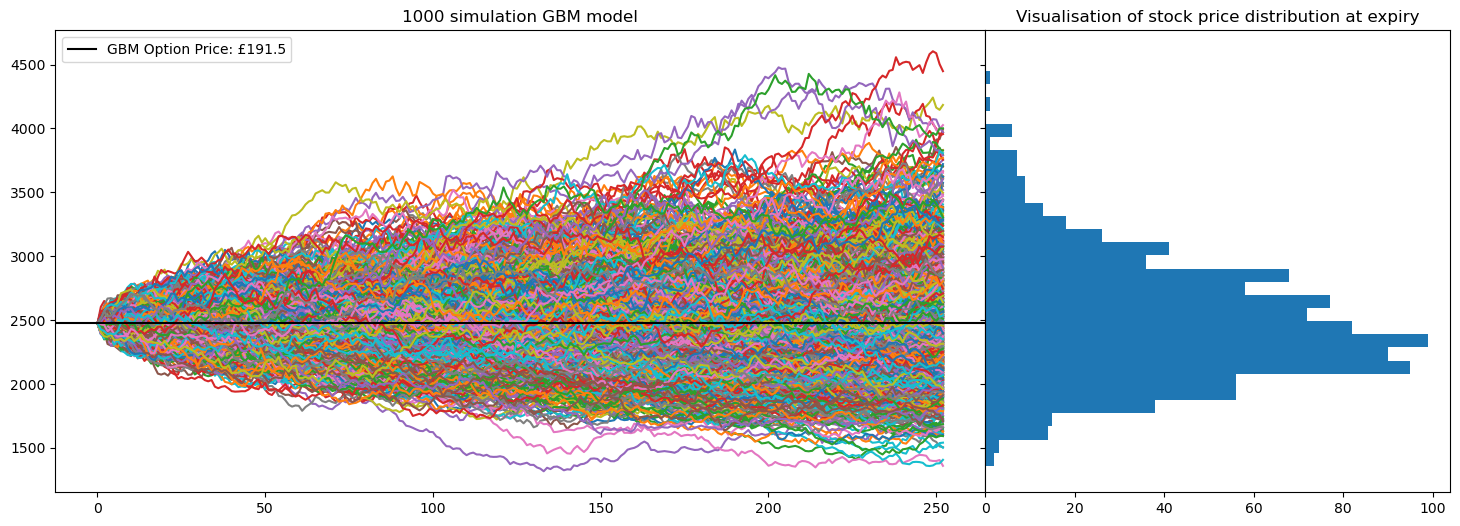

In [16]:
def visualise_GBM(simulations, S_0, r, sigma, T, K, d_t, European=False, Asian=False)

    results_df = pd.DataFrame(
        np.column_stack([
            GBM_model(S_0, r, sigma, T, d_t)
            for _ in range(simulations)
        ])
    )

    european_payoffs = payoff(results_df.iloc[-1], K)
    
    S_t_mean = results_df.mean(axis=0)
    asian_payoffs = payoff(S_t_mean.mean(), k)
    
    optionPrice = np.exp(-r * T) * european_payoffs.mean()

    fig, (ax_plot, ax_hist) = plt.subplots(
        1, 2, 
        figsize=(18,6), 
        width_ratios=[2,1],
        sharey = True
    )
    ax_plot.plot(results_df.to_numpy())
    ax_plot.axhline(S_0, color="black", label=f"GBM Option Price: £{optionPrice:.1f}")
    ax_plot.set_title(f"{simulations} simulation GBM model for ___ stocks")
    ax_plot.legend()

    ax_hist.hist(
        results_df.iloc[-1], 
        bins=30,
        orientation = "horizontal"
    )
    ax_hist.set_title("Visualisation of stock price distribution at expiry")

    # Remove the gap between the axes
    fig.subplots_adjust(wspace=0)

    # Hide redundant y-axis labels/ticks on histogram
    ax_hist.tick_params(axis="y", labelleft=False)

    fig.show()

In [19]:
BS_optionPrice = Black_Scholes(S_0, r, sigma, T, K)
print(f"The Black-Scholes model gave an option price of £{BS_optionPrice}.")

207.3734312639649

In [ ]:
simulations = 1000
visualise_GBM(simulations, S_0, r, sigma, T, K, d_t)
visualise_GBM(simulations, S_0, r, sigma, T, K, d_t, Asian=True)

Monte Carlo pricing was validated against the Black–Scholes analytical solution for European options. 
The model was subsequently extended to Asian options, demonstrating the flexibility of Monte Carlo for path-dependent derivatives. 
Antithetic variates were implemented as a variance-reduction technique to improve computational efficiency.